## **Part 1: Understanding the Problem and the People Behind the Data:**

**1. Count total patients:**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import  plotly.express as px
import sklearn as slr 
import warnings

In [2]:
data= pd.read_csv("https://raw.githubusercontent.com/rajesh-coventry/Projects/refs/heads/master/00_DataSets/27_Lung_Cancer_Dataset.csv")

In [3]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0


In [4]:
data.shape

(890000, 17)

In [5]:
data["id"].nunique()

890000

So, the dataset contains nearly 9 lakhs of individual's data; contains 17 different features recorded from survey.

**2. Check for missing values:**

In [6]:
data.isnull().sum().any()

np.False_

In [7]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [8]:
data[data["age"]==np.nan]

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived


In [9]:
data["cancer_stage"].unique()

array(['Stage I', 'Stage III', 'Stage IV', 'Stage II'], dtype=object)

In [10]:
data["smoking_status"].unique()== np.nan

array([False, False, False, False])

We do check by using different approachs to ensure because sometimes pandas outputs `no missing data found` but in actual, the dataset contains missing values. 

No missing data found. 

**Duplicacy of data:**

In [11]:
data.duplicated(keep=False).any() # catch all duplicates, not just first ones

np.False_

The dataset contains no duplicate rows. But again this is dependent on the pandas version, machine we're using, how duplicacy is being checked, how these two softwares reads the data and many other things. There may be rows that are duplicate of another. But, for now, conider no duplicate rows.

**3. Basic summary statistics and data :**

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

In [13]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0


**Convert `age` to integer:**

In [14]:
# convert age to numeric: 
data["age"] = data["age"].astype(int)

In [15]:
data["age"].dtype

dtype('int64')

**Check the unique values in `gender` column:**

In [16]:
data["gender"].unique()

array(['Male', 'Female'], dtype=object)

**Convert `diagnosis_date` datatype into datetime format:**

In [17]:
data["diagnosis_date"]= pd.to_datetime(data["diagnosis_date"])

In [18]:
data["diagnosis_date"].dtype

dtype('<M8[ns]')

**Check unique values in `cancer_stage`	`family_history` columns:**

In [19]:
data[["cancer_stage", "family_history"]].nunique()

cancer_stage      4
family_history    2
dtype: int64

In [20]:
data[["cancer_stage", "family_history"]].value_counts()

cancer_stage  family_history
Stage I       No                111621
Stage II      Yes               111463
Stage IV      No                111446
Stage III     Yes               111380
              No                111214
Stage IV      Yes               111081
Stage II      No                110900
Stage I       Yes               110895
Name: count, dtype: int64

**Check unique values in `smoking_status`:**

In [21]:
data["smoking_status"].unique()

array(['Passive Smoker', 'Former Smoker', 'Never Smoked',
       'Current Smoker'], dtype=object)

**Convert `end_treatment_date` into `datetime` datatype:**

In [22]:
data["end_treatment_date"]= pd.to_datetime(data["end_treatment_date"])

In [23]:
data["end_treatment_date"].dtype

dtype('<M8[ns]')

**Unique values in `treatment_type`:**

In [24]:
print(data["treatment_type"].nunique())
print(data["treatment_type"].unique())

4
['Chemotherapy' 'Surgery' 'Combined' 'Radiation']


**4. Age distribution histogram:**

In [25]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [26]:
data.sample(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
480496,480497,62,Male,Estonia,2020-12-29,Stage I,Yes,Passive Smoker,26.5,224,1,1,0,0,Combined,2022-11-28,1
595881,595882,68,Male,Finland,2017-12-10,Stage II,Yes,Never Smoked,19.8,234,0,0,0,0,Combined,2019-03-24,1
230718,230719,63,Female,Luxembourg,2022-12-13,Stage IV,No,Former Smoker,17.4,152,1,1,0,0,Surgery,2024-12-09,0


**Age distribution using `histogram` + `density plot` + `rug` plots:**

- Histogram divides the age values into different bins or segments and plot bars for each bin by counting the number of patients in each bin. 

- Density plots display the overall distribution of data using kernal density estimation.

- Rug plots helps to identify the data distribution by showing the density of observations over the given range.

In [27]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

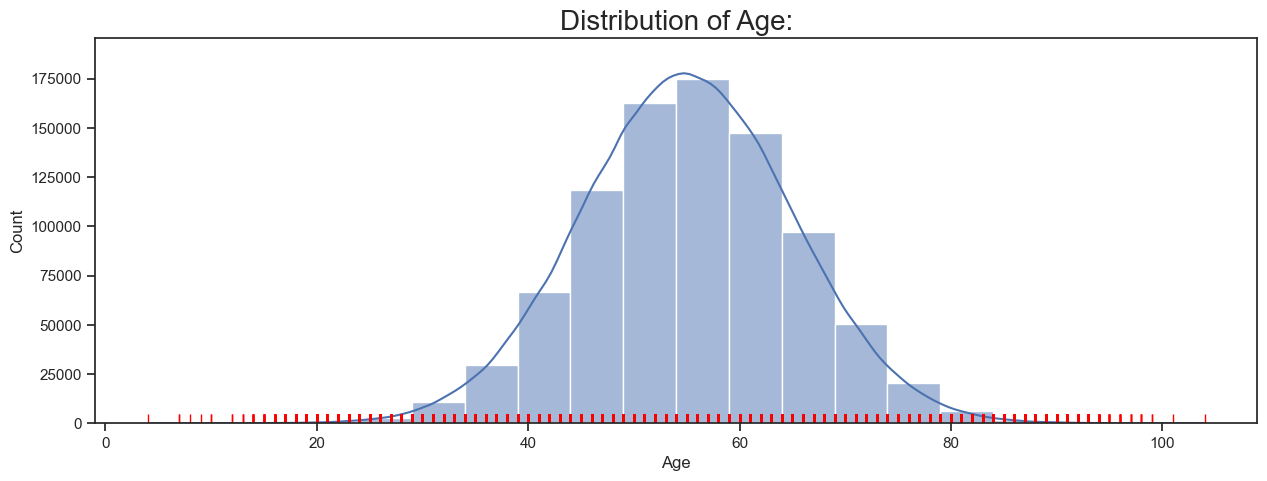

In [28]:
plt.figure(figsize=(15, 5))
# set theme for plot:
sns.set_theme(style="ticks", color_codes=True)
sns.histplot(data= data, x= "age", bins= 20, kde= True) 
# add rugplot at the bottom of this plot: 
sns.rugplot(data= data, x= "age", color= "red")
plt.title("Distribution of Age:", fontsize= 20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The age distribution is bell-shaped curve centered in the early-to-mid 50s, with the bulk of people falling between roughly 40 and 70 years old. The smooth KDE and histogram bars taper off symmetrically toward younger (around 18–30) and older ages (above 80), though the red “rug” ticks reveal a few outliers below 20 and above 90. Overall, it’s an approximately normal distribution with most participants clustered around a mean of about 53.

**5. Age distribution by gender:**

In [29]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [30]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0


Now, check the age distribution according to gender:

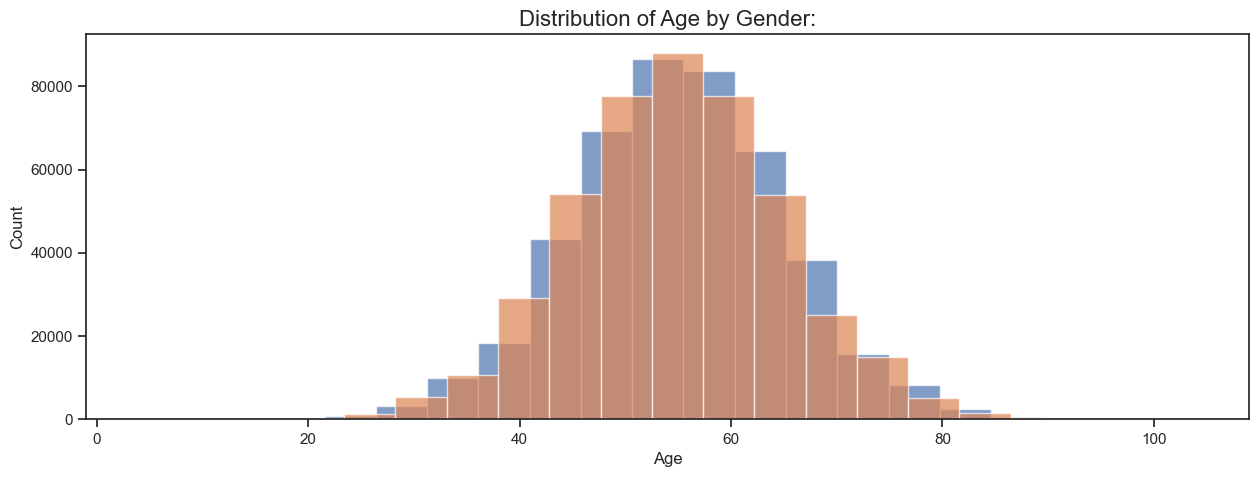

In [31]:
plt.figure(figsize=(15, 5))

data.groupby(by= "gender")["age"].plot(kind= "hist", bins= 20, alpha= 0.7)
plt.title("Distribution of Age by Gender:", fontsize= 16)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

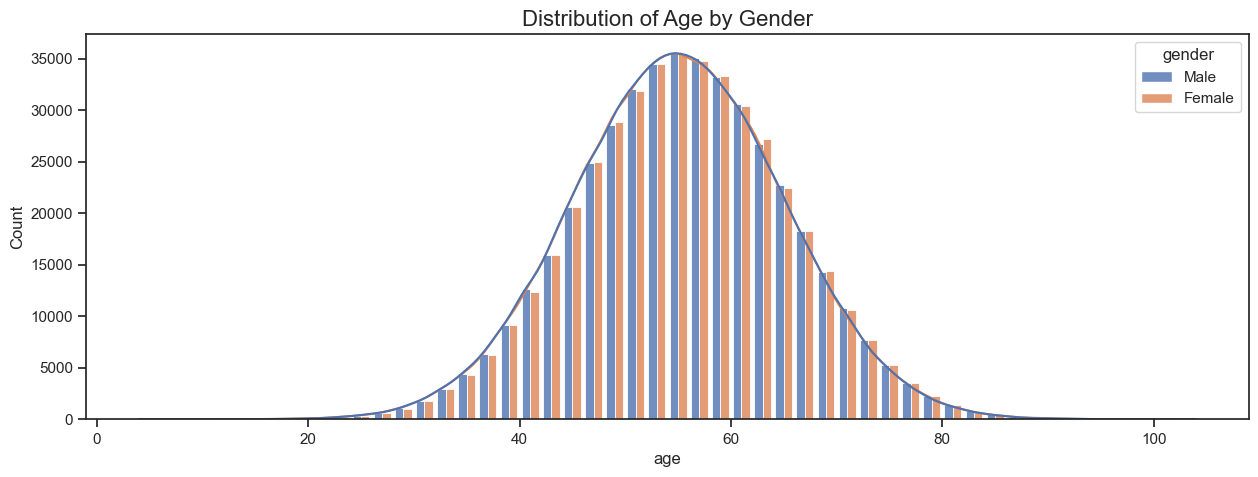

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

sns.histplot(
    data    = data,
    x       = "age",
    hue     = "gender",
    multiple= "dodge",    # pull the bars apart
    shrink  = 0.8,        # make them a bit narrower
    binwidth= 2,          # adjust bin size if you like
    alpha   = 0.8,
    kde= True
)
plt.title("Distribution of Age by Gender", fontsize=16)
plt.show()

In [33]:
# check the available styles for the plot:
style = plt.style.available
style

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

The distributions for both male and female are almost normal as seen from above histograms.

**6. Gender ratio:**

In [34]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [35]:
data["gender"].value_counts()

gender
Male      445134
Female    444866
Name: count, dtype: int64

<Axes: ylabel='proportion'>

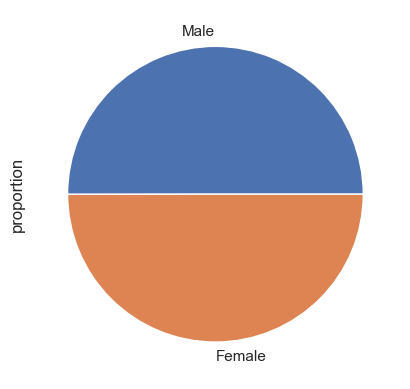

In [36]:
data["gender"].value_counts(normalize= True).plot.pie()

There is perfect balance between males and females 50-50.

**7. Country-wise patient count:**

In [37]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [38]:
data["country"].nunique()

27

Text(0, 0.5, '')

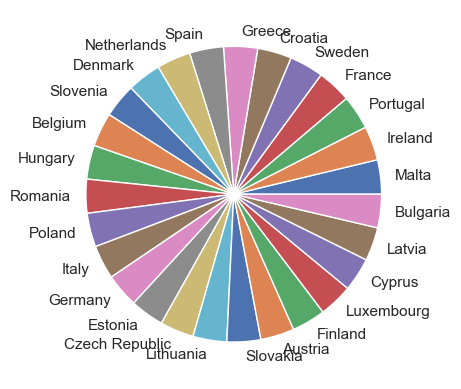

In [39]:
data["country"].value_counts().plot(kind= "pie")
plt.xlabel("")
plt.ylabel("")

This implies, people from 27 different countrues in almost equal ratio. This is too perfect scenario and generally difficult in real-world datasets.

**8. Time trend of diagnosis (by year):**

In [40]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')

In [41]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0


Here, from diagnosis_date column, we extract the year and then count the total number of diagonised cases per year to get an idea of the trend.

In [42]:
data["year"]= data["diagnosis_date"].dt.year

In [43]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023


Text(0, 0.5, 'Diagnosis Counts')

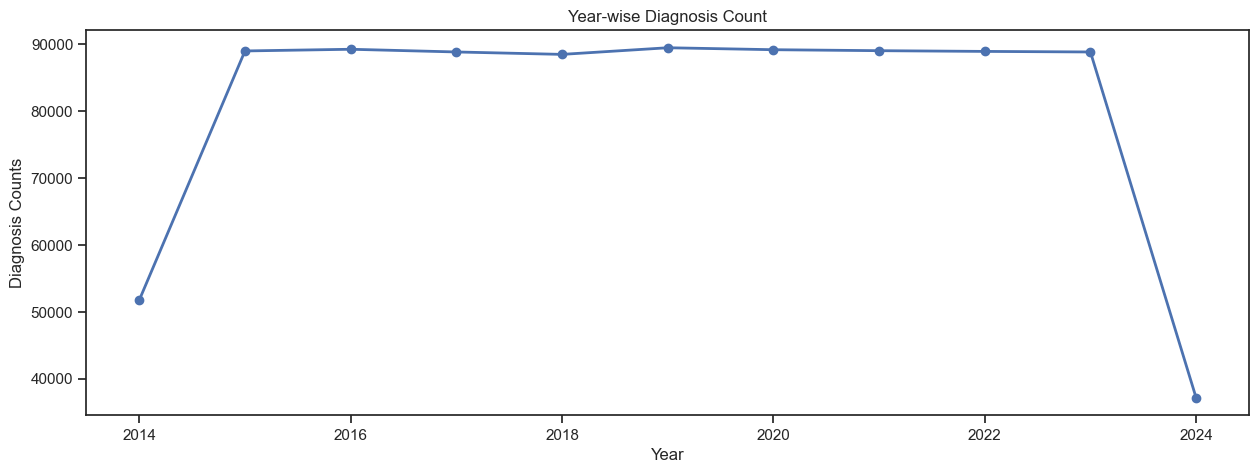

In [44]:
data.groupby(by= "year")["year"].value_counts().plot(kind= "line", figsize= (15, 5), marker= "o", linewidth= 2)
plt.title("Year-wise Diagnosis Count")
plt.xlabel("Year")
plt.ylabel("Diagnosis Counts")

From 2014’s ~52 000 diagnoses there’s a steep rise to about 89 000 in 2015–2016, after which annual counts hold remarkably steady—fluctuating only marginally between ~88 000 and ~89.5 000—from 2017 through 2023. The sharp fall to ~37 000 in 2024 almost certainly signals incomplete or anomalous data for the current year rather than a true drop in cases.

**9. Distribution of cancer stages:**

In [45]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year'],
      dtype='object')

In [46]:
data["cancer_stage"].nunique()

4

In [47]:
data["cancer_stage"].unique()

array(['Stage I', 'Stage III', 'Stage IV', 'Stage II'], dtype=object)

<Axes: xlabel='cancer_stage'>

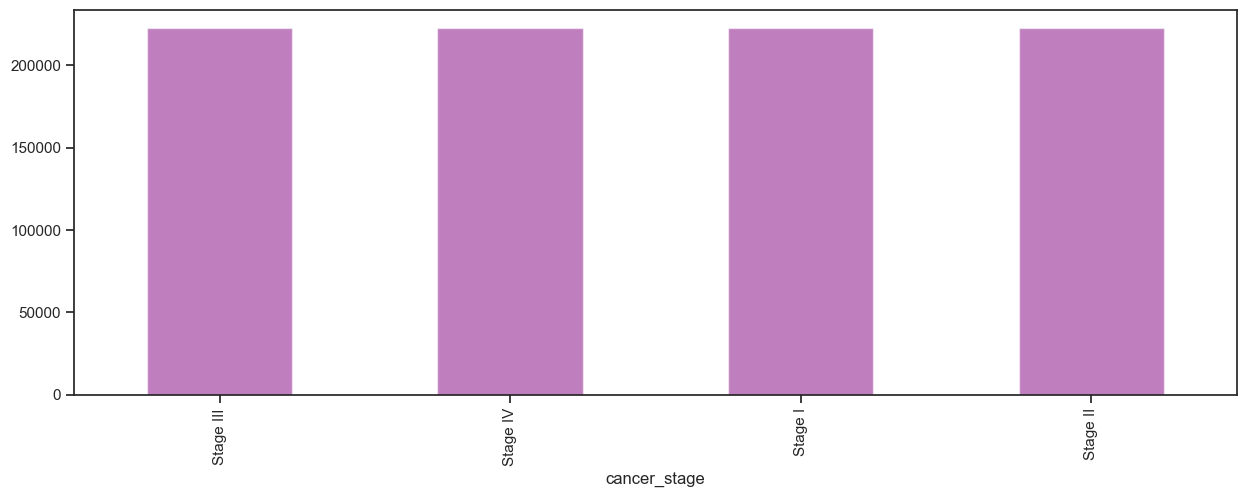

In [48]:
data["cancer_stage"].value_counts().plot(kind= "bar", figsize= (15, 5), color= "purple", alpha= 0.5)

Nothing unusual, everything is symmetrical, not comon in real world datasets. This dataset is probably a synthetic dataset created using python libraries like `faker`, good for proto-typing in the initial stages of data analysis and model training. 

### **10. Age vs. Cancer Stage:**

In [49]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023


**1. Patients in different age-groups:**

In [50]:
data["age_groups"]= pd.cut(data["age"], bins= [0, 20, 40, 60, 80, 100], labels= ["0-20", "20-40", "40-60", "60-80", "80-100"])

In [51]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

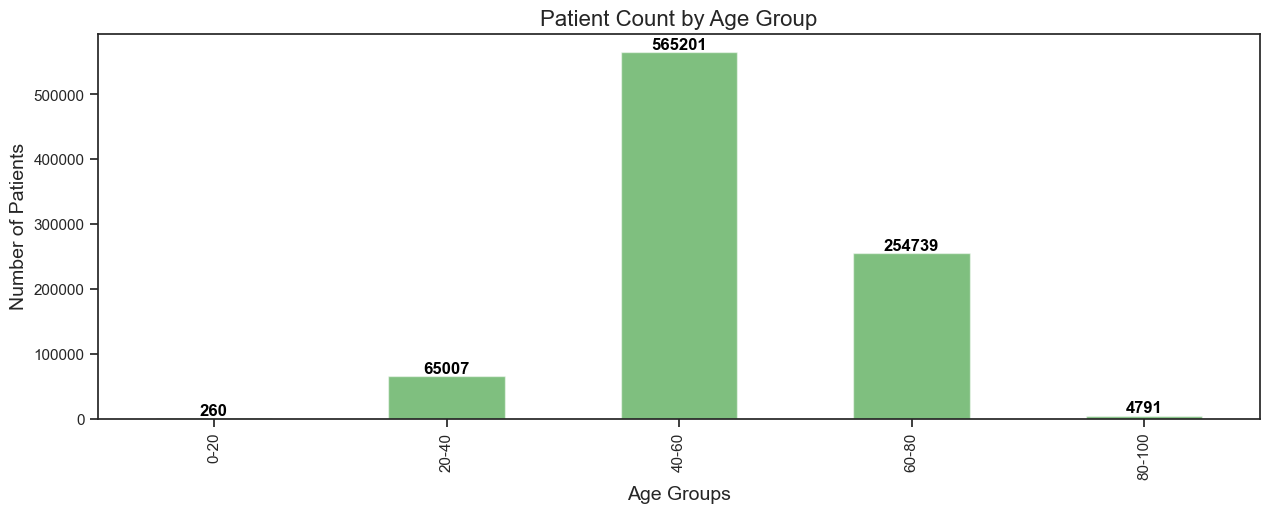

In [52]:
# Plot the age group counts as a bar plot:

ax = data["age_groups"].value_counts().sort_index().plot(
    kind="bar", figsize=(15, 5), color="green", alpha=0.5
)

# Add corresponding numbers on top of each bar
for p in ax.patches:
    # Get the height of each bar (i.e., the count)
    count = int(p.get_height())
    # Place the text at the center of each bar
    ax.annotate(
        str(count),                              # Text to display
        (p.get_x() + p.get_width() / 2, count),  # X, Y coordinates
        ha="center",                             # Horizontal alignment
        va="bottom",                             # Vertical alignment
        fontsize=12,                             # Font size
        fontweight="bold",                       # Make text bold
        color="black"                            # Text color
    )

# Add axis labels and title for clarity
ax.set_xlabel("Age Groups", fontsize=14)
ax.set_ylabel("Number of Patients", fontsize=14)
ax.set_title("Patient Count by Age Group", fontsize=16)
plt.show()

- The majority of patients are in the 40-60 age group, indicating this demographic may have higher healthcare needs.

- There is a significant drop in patient numbers for age groups 20-40 and 80-100, suggesting fewer healthcare issues or lower engagement in these groups.

**2. Age vs. Cancer Stage:**

In [53]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

<Axes: xlabel='age_groups', ylabel='count'>

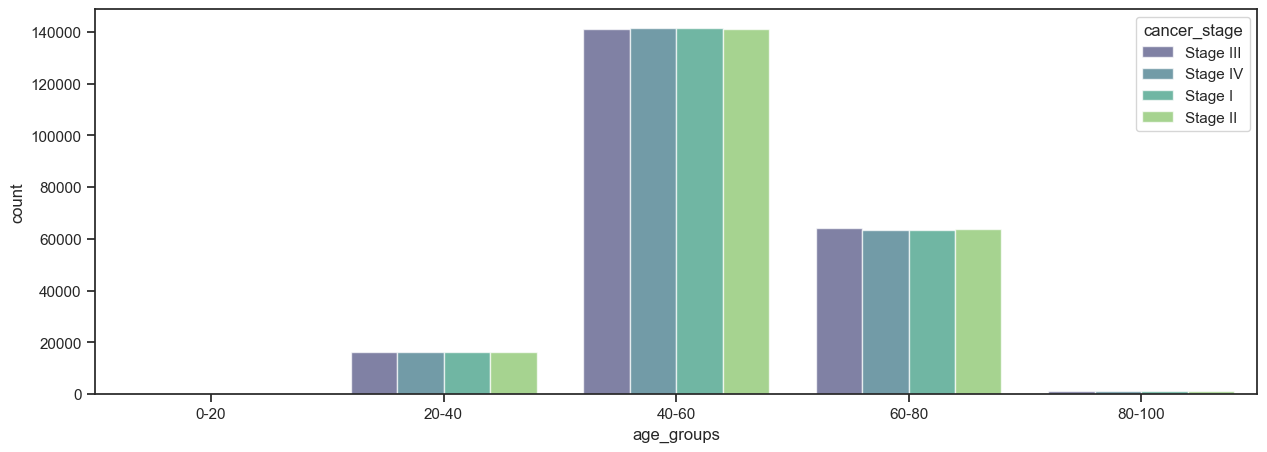

In [54]:
ptt= data.groupby(by= "age_groups", observed= False)["cancer_stage"].value_counts().reset_index()
plt.figure(figsize= (15, 5))
sns.barplot(data= ptt, x= "age_groups", y= "count", hue= "cancer_stage", palette= "viridis", alpha= 0.7)
# add annotations for each bars 

In [55]:
# Get a list of all available color maps
colormaps = plt.colormaps()
colormaps

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

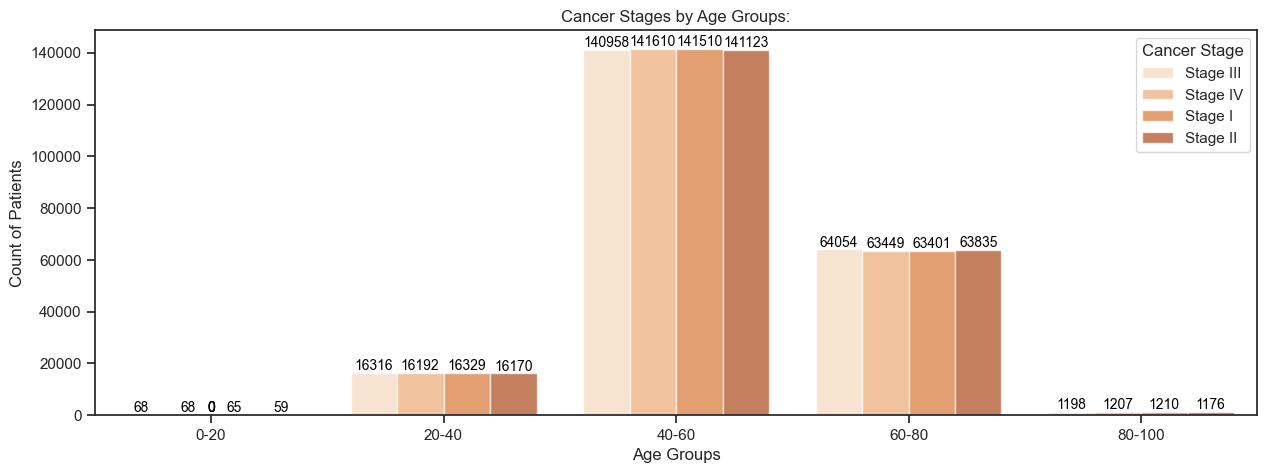

In [56]:
plt.figure(figsize=(15, 5))
bar_plot = sns.barplot(data=ptt, x="age_groups", y="count", hue="cancer_stage", palette= "Oranges" , alpha=0.7)

# Add annotations for each bar
for p in bar_plot.patches:
    bar_plot.annotate(
        f'{int(p.get_height())}',  # Display the count as an integer
        (p.get_x() + p.get_width() / 2, p.get_height()),  # Position on top of the bar
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10,  # Font size
        color='black'  # Font color
    )

plt.title('Cancer Stages by Age Groups:')
plt.xlabel('Age Groups')
plt.ylabel('Count of Patients')
plt.legend(title='Cancer Stage')
plt.show()

- The age group 40-60 has the largest number of patients, with a significant presence of Stage II and Stage III cancers.

- **Stage Distribution**:
  - **`Stage III`**: Predominantly found in the 40-60 age group.
  - **`Stage II`**: Also significant in the 40-60 group, but less than Stage III.
  - **`Stage IV`**: Very few cases are recorded across age groups.

- Patient counts generally increase in the middle age groups (40-60), then decline in older age groups (60-80 and 80-100).

- The younger age group (0-20) has the lowest patient counts across all stages.

**11. Gender vs. Cancer Stage:**

In [57]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [58]:
data["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [59]:
gcs= data.groupby(by= "gender")["cancer_stage"].value_counts().reset_index()
gcs

,gender,cancer_stage,count
0,Female,Stage III,111322
1,Female,Stage IV,111218
2,Female,Stage I,111179
3,Female,Stage II,111147
4,Male,Stage I,111337
5,Male,Stage IV,111309
6,Male,Stage III,111272
7,Male,Stage II,111216


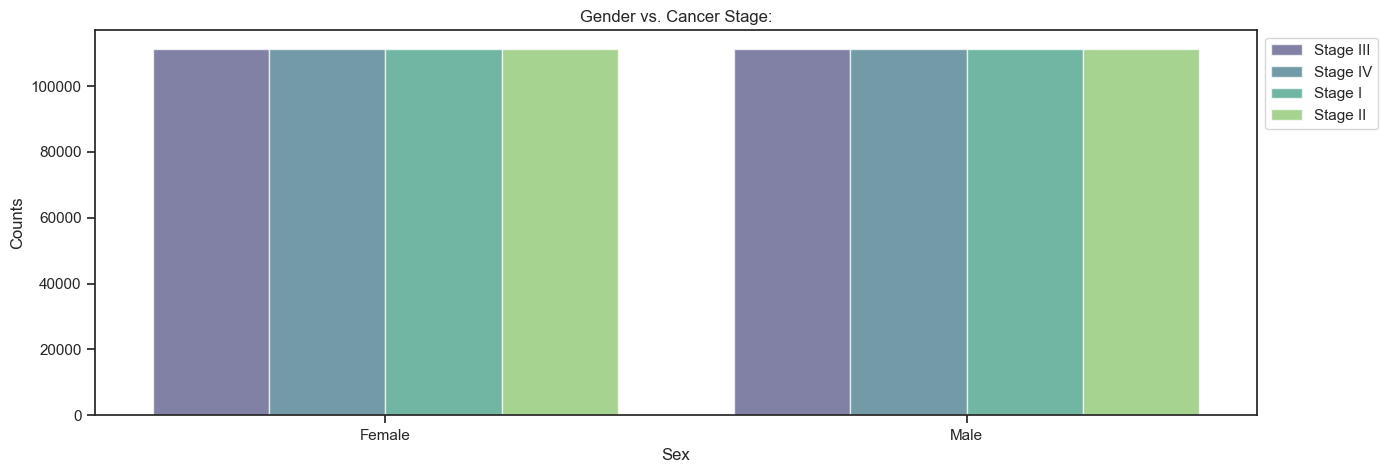

In [60]:
plt.figure(figsize= (15, 5))
sns.barplot(data= gcs, x= "gender", y= "count", hue= "cancer_stage", palette= "viridis", alpha= 0.7)
# Place legend outside the plot: 
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Gender vs. Cancer Stage:")
plt.xlabel("Sex")
plt.ylabel("Counts")
plt.show()

**12. Family history presence:**

In [61]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [62]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [63]:
data["family_history"].unique()

array(['Yes', 'No'], dtype=object)

<Axes: ylabel='proportion'>

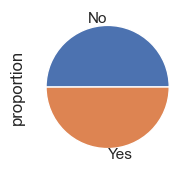

In [64]:
plt.figure(figsize= (15, 2))
data["family_history"].value_counts(normalize= True).plot.pie()

**13. Family history vs. stage:**

In [65]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [66]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [67]:
pd.crosstab(data["family_history"], data["cancer_stage"])

cancer_stage,Stage I,Stage II,Stage III,Stage IV
family_history,,,,
No,111621,110900,111214,111446
Yes,110895,111463,111380,111081


<Axes: xlabel='family_history'>

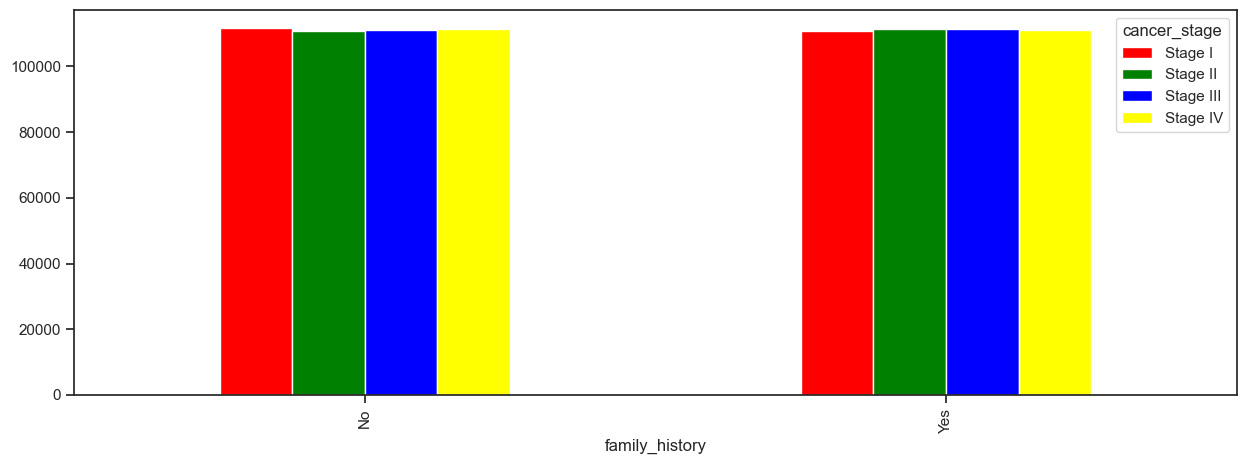

In [68]:
pd.crosstab(data["family_history"], data["cancer_stage"]).plot(kind= "bar", figsize= (15, 5), stacked= False, color= ["red", "green", "blue", "yellow"])

**14. Smoking status distribution:**

In [69]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [70]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [71]:
data["smoking_status"].unique()

array(['Passive Smoker', 'Former Smoker', 'Never Smoked',
       'Current Smoker'], dtype=object)

Let's find the distribution of different smooking status in the dataset:

<Axes: xlabel='smoking_status'>

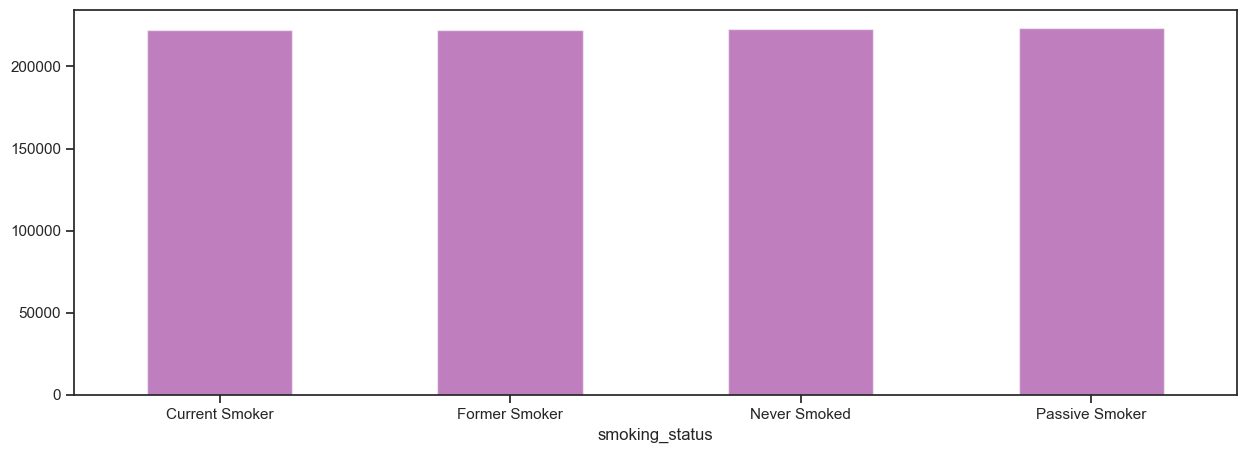

In [72]:
data.groupby(by= "smoking_status")["smoking_status"].value_counts().plot(kind= "bar", figsize= (15, 5), color= "purple", alpha= 0.5, rot= 0)

**15. Smoking status by gender:**

In [73]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [74]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


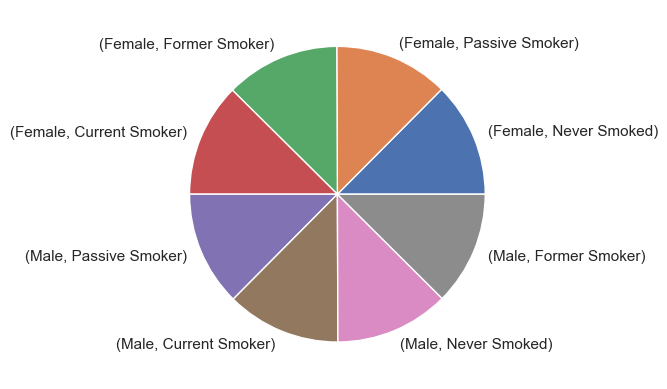

In [75]:
data.groupby(by= "gender")["smoking_status"].value_counts(normalize=True).plot(kind= "pie")
plt.xlabel("")
plt.ylabel("")
plt.show()

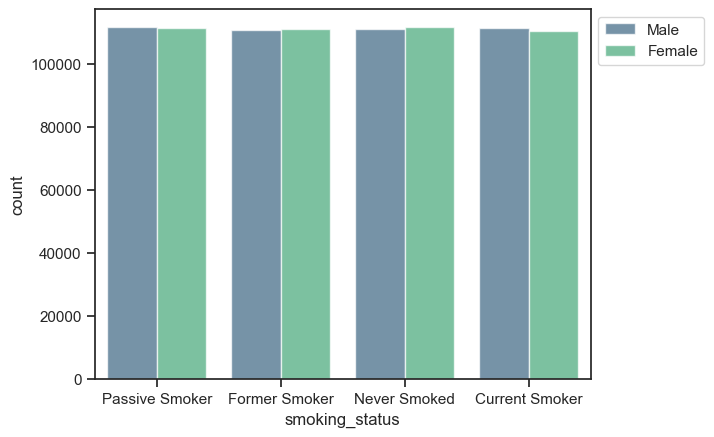

In [76]:
sns.countplot(data= data, x= "smoking_status", hue= "gender", palette= "viridis", alpha= 0.7)
# place legend outside the plot: 
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

The dataset is too perfect (too symmetrical) to analyze for. 

**16. Correlation matrix (heatmap):**

In [77]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [78]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [82]:
# Filter out numerical columns that make sense for correlation analysis
# We'll exclude ID columns and categorical codes, and focus on continuous variables

# List all columns and select relevant numeric ones
numeric_cols = ['age', 'bmi', 'cholesterol_level']

# Compute the correlation matrix for these columns
corr_matrix = data[numeric_cols].corr()

# Display the correlation matrix
print("Correlation matrix for selected numeric columns:")
print(corr_matrix)

Correlation matrix for selected numeric columns:
                        age       bmi  cholesterol_level
age                1.000000  0.000915           0.001799
bmi                0.000915  1.000000           0.746905
cholesterol_level  0.001799  0.746905           1.000000


<Axes: >

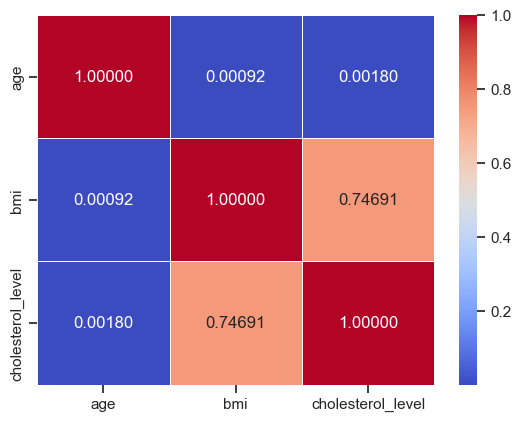

In [84]:
sns.heatmap(data= corr_matrix, annot= True, cmap= "coolwarm", fmt= ".5f", linewidths= 0.5)

`Cholestrol_level` and `bmi` are highly correlated indicating linear relationship ie. as the one variable increases, the other also increases in a linear fashion considering other variables constant. 

**17. BMI distribution and outliers:**

In [85]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [86]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [87]:
data["bmi"].describe()

count    890000.000000
mean         30.494172
std           8.368539
min          16.000000
25%          23.300000
50%          30.500000
75%          37.700000
max          45.000000
Name: bmi, dtype: float64

- **`Mean` (`30.49`)**: The average BMI (Body Mass Index) of the population, suggesting that the overall group tends toward being overweight or obese, as a BMI over 25 is considered overweight.

- **`Standard Deviation` (`8.37`)**: Measures the variability or dispersion of BMI values from the mean. A relatively high standard deviation indicates a wide range of BMI values in the dataset.

- **`Minimum` (`16.00`)**: The lowest BMI recorded, which may indicate underweight individuals or possible data anomalies.

- **`25th Percentile` (`23.30`)**: Indicates that 25% of the population has a BMI of 23.3 or lower, which is within the normal weight range.

- **`Median` (`50th Percentile, 30.50`)**: The middle value of the dataset. Half of the population has a BMI less than or equal to 30.5, further highlighting that the population leans towards being overweight.

- **`75th Percentile` (`37.70`)**: Indicates that 75% of the population has a BMI of 37.7 or lower, showing that a significant portion falls into the higher BMI categories.

- **`Maximum` (`45.00`)**: The highest BMI recorded, indicating severe obesity in some individuals. 

**18. `BMI` vs. `age`:**

In [88]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [89]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


C:\Users\MyMachine\AppData\Local\Temp\ipykernel_5888\3961030760.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data= data, x= "age", y= "bmi", palette= "viridis", alpha= 0.7)


<Axes: xlabel='age', ylabel='bmi'>

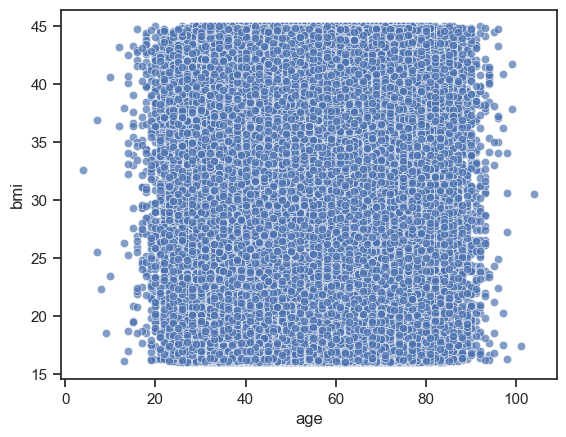

In [91]:
sns.scatterplot(data= data, x= "age", y= "bmi", palette= "viridis", alpha= 0.7)

- There are no clear trends or patterns, suggesting that `BMI` values are spread out relatively evenly across all age groups.

- Most BMI values cluster between 20 and 35, with fewer occurrences at the extremes (very low or very high BMI).

- The scatter plot illustrates a wide range of BMI values across different ages, with a concentration in the middle BMI range, indicating no strong correlation between age and BMI.

**19. Cholesterol level vs. age:**

In [92]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [93]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [94]:
data[["cholesterol_level", "age"]].head(4)

,cholesterol_level,age
0,199,64
1,280,50
2,268,65
3,241,51


<Axes: xlabel='age', ylabel='cholesterol_level'>

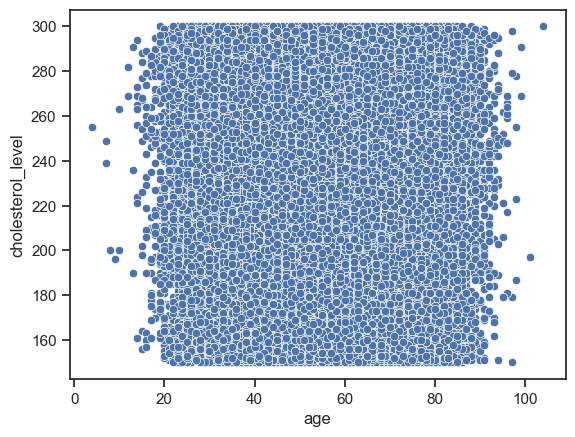

In [95]:
sns.scatterplot(data= data, x= "age", y= "cholesterol_level")

**20. Survival rate overall:**

In [96]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [97]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [100]:
data["survived"].value_counts(normalize= True)

survived
0    0.779771
1    0.220229
Name: proportion, dtype: float64

<Axes: ylabel='proportion'>

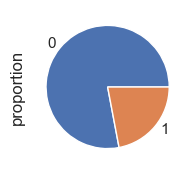

In [102]:
plt.figure(figsize= (3,2))
data["survived"].value_counts(normalize= True).plot.pie()

Among all the diagnosed patients, only about 20% were survived and, remaining 78% did not make it to recovery.

**21. Survival rate by gender:**

In [103]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [104]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


Text(0, 0.5, '')

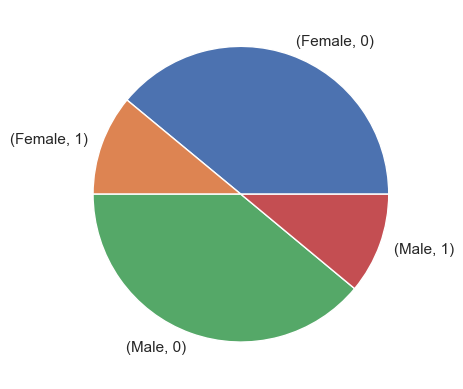

In [108]:
data.groupby(by= "gender")["survived"].value_counts(normalize=True).plot(kind= 'pie')
plt.ylabel("")

There is not much difference in survival rate according to gender. 

**22. Age group vs. survival:**

In [109]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [112]:
data.groupby(by= "age_groups", observed=False)["survived"].value_counts()

age_groups  survived
0-20        0              192
            1               68
20-40       0            50890
            1            14117
40-60       0           440596
            1           124605
60-80       0           198578
            1            56161
80-100      0             3739
            1             1052
Name: count, dtype: int64

<Axes: xlabel='age_groups,survived'>

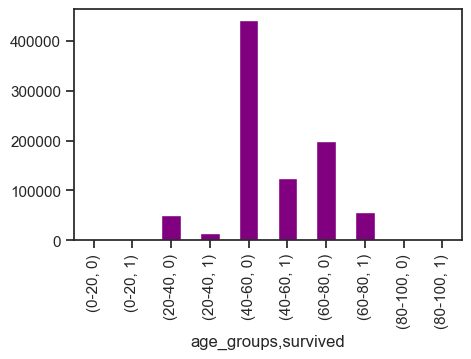

In [121]:
plt.figure(figsize= (5, 3))
data.groupby(by= "age_groups", observed=False)["survived"].value_counts(normalize=False).plot(kind= "bar", color= "purple",)

<Axes: xlabel='age_groups,survived'>

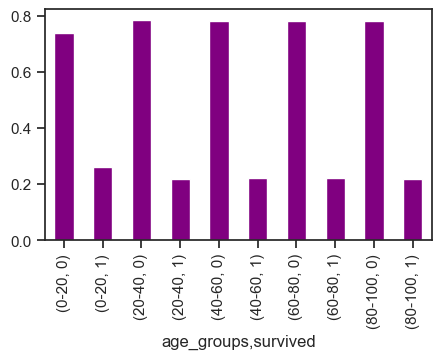

In [122]:
plt.figure(figsize= (5, 3))
data.groupby(by= "age_groups", observed=False)["survived"].value_counts(normalize=True).plot(kind= "bar", color= "purple",)

There is no significant difference between survived and not survived in different age groups.

**23. Show a few anonymized patient examples:**

In [123]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [124]:
data.sample(n=4)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
671166,671167,39,Male,Poland,2022-10-25,Stage IV,No,Never Smoked,19.6,164,1,0,0,0,Chemotherapy,2023-06-15,0,2022,20-40
477696,477697,57,Male,Sweden,2018-12-02,Stage I,Yes,Current Smoker,42.7,271,1,0,0,0,Radiation,2019-12-20,0,2018,40-60
174885,174886,44,Female,Lithuania,2021-04-01,Stage II,Yes,Never Smoked,34.2,250,0,1,0,0,Combined,2023-02-19,0,2021,40-60
876048,876049,64,Female,Sweden,2019-03-14,Stage II,No,Former Smoker,34.3,287,1,1,0,0,Radiation,2020-03-23,0,2019,60-80


In [128]:
data[["age", "cancer_stage", "survived", "treatment_type"]].sample(5)

,age,cancer_stage,survived,treatment_type
28900,45,Stage I,0,Combined
476409,67,Stage I,1,Radiation
716276,60,Stage IV,0,Combined
350490,53,Stage III,0,Chemotherapy
227861,48,Stage III,0,Chemotherapy


**24. Timeline from diagnosis to treatment end:**

In [129]:
data.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'year', 'age_groups'],
      dtype='object')

In [130]:
data.head(3)

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,year,age_groups
0,1,64,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0,2016,60-80
1,2,50,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1,2023,40-60
2,3,65,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0,2023,60-80


In [133]:
data["treatment_days"]= (data["end_treatment_date"]- data["diagnosis_date"]).dt.days

In [134]:
data["treatment_days"].head(20)

0     523
1     424
2     370
3     443
4     406
5     725
6     350
7     189
8     351
9     729
10    309
11    458
12    470
13    296
14    312
15    477
16    573
17    726
18    275
19    377
Name: treatment_days, dtype: int64

In [139]:
data["treatment_days"].describe()

count    890000.000000
mean        458.087170
std         139.326048
min         183.000000
25%         367.000000
50%         458.000000
75%         550.000000
max         730.000000
Name: treatment_days, dtype: float64

<Axes: xlabel='treatment_days'>

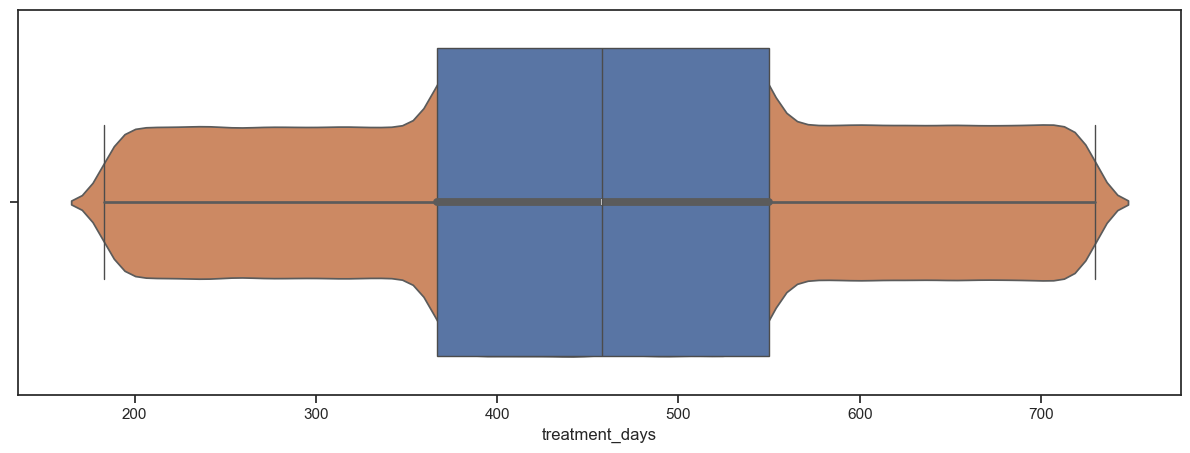

In [144]:
plt.figure(figsize= (15, 5))
sns.boxplot(data= data, x= "treatment_days")
sns.violinplot(data= data, x= "treatment_days")

- The shape of the violin indicates that most values are concentrated around the middle range (approximately 350 to 450 days).

- The wider sections of the violin represent higher density, indicating that more individuals have treatment durations within those ranges.

- The box in the center shows the interquartile range (IQR) and the median of the dataset.

- The thin lines extending from the box indicate the range of the data, which may include outliers beyond this range.